# Mutual Fund Analytics
## Day 4 - Fund Performance Analytics

### Objectives
- Compute Daily Returns
- Compute CAGR
- Compute Sharpe Ratio
- Compute Sortino Ratio
- Compute Alpha & Beta
- Compute Maximum Drawdown
- Build Fund Scorecard
- Compare Funds with Benchmark

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import linregress

plt.style.use("ggplot")

print("Libraries Loaded Successfully ✔")

Libraries Loaded Successfully ✔


In [2]:
nav = pd.read_csv("../data/processed/clean_nav.csv")

performance = pd.read_csv("../data/processed/clean_performance.csv")

benchmark = pd.read_csv("../data/raw/10_benchmark_indices.csv")

print("NAV Shape :", nav.shape)
print("Performance Shape :", performance.shape)
print("Benchmark Shape :", benchmark.shape)

NAV Shape : (46000, 3)
Performance Shape : (40, 20)
Benchmark Shape : (8050, 3)


In [3]:
nav["date"] = pd.to_datetime(nav["date"])

print(nav.dtypes)

amfi_code             int64
date         datetime64[us]
nav                 float64
dtype: object


In [4]:
nav = nav.sort_values(["amfi_code", "date"])

nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [5]:
nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

nav.head(10)

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210
5,100016,2022-01-10,510.7136,-0.008639
6,100016,2022-01-11,513.5542,0.005562
7,100016,2022-01-12,512.3195,-0.002404
8,100016,2022-01-13,510.2445,-0.004050
9,100016,2022-01-14,514.3636,0.008073


In [6]:
nav["daily_return"].isnull().sum()

np.int64(40)

In [7]:
daily_returns = nav.dropna(subset=["daily_return"])

daily_returns.head()

,amfi_code,date,nav,daily_return
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210
5,100016,2022-01-10,510.7136,-0.008639


In [8]:
daily_returns.to_csv(
    "../data/processed/returns_computed.csv",
    index=False
)

print("returns_computed.csv Saved Successfully ✔")

returns_computed.csv Saved Successfully ✔


In [9]:
annual_return = (
    daily_returns.groupby("amfi_code")["daily_return"]
    .apply(lambda x: ((1 + x).prod()) ** (252 / len(x)) - 1)
)

annual_return = annual_return.reset_index()

annual_return.columns = [
    "amfi_code",
    "annualized_return"
]

annual_return.head()

,amfi_code,annualized_return
0,100016,0.025435
1,100025,0.042987
2,100033,0.289279
3,101206,0.226265
4,101207,0.076502


In [10]:
annual_return.to_csv(
    "../data/processed/annualized_returns.csv",
    index=False
)

print("Annual Returns Saved ✔")

Annual Returns Saved ✔


In [11]:
funds = performance[['amfi_code', 'scheme_name']]

nav = nav.merge(funds, on='amfi_code', how='left')

nav.head()

,amfi_code,date,nav,daily_return,scheme_name
0,100016,2022-01-03,520.4608,NaN,HDFC Top 100 Fund - Regular Plan - Growth
1,100016,2022-01-04,515.0971,-0.010306,HDFC Top 100 Fund - Regular Plan - Growth
2,100016,2022-01-05,521.7239,0.012865,HDFC Top 100 Fund - Regular Plan - Growth
3,100016,2022-01-06,515.7880,-0.011377,HDFC Top 100 Fund - Regular Plan - Growth
4,100016,2022-01-07,515.1639,-0.001210,HDFC Top 100 Fund - Regular Plan - Growth


In [12]:
def calculate_cagr(start_nav, end_nav, years):
    return ((end_nav / start_nav) ** (1 / years) - 1) * 100

In [13]:
cagr_list = []

for code in nav['amfi_code'].unique():

    df = nav[nav['amfi_code'] == code].sort_values("date")

    scheme = df['scheme_name'].iloc[0]

    try:
        cagr_1 = calculate_cagr(
            df.iloc[-252]['nav'],
            df.iloc[-1]['nav'],
            1
        )

        cagr_3 = calculate_cagr(
            df.iloc[-756]['nav'],
            df.iloc[-1]['nav'],
            3
        )

        cagr_5 = calculate_cagr(
            df.iloc[0]['nav'],
            df.iloc[-1]['nav'],
            5
        )

    except:
        cagr_1 = np.nan
        cagr_3 = np.nan
        cagr_5 = np.nan

    cagr_list.append([
        code,
        scheme,
        cagr_1,
        cagr_3,
        cagr_5
    ])

cagr_df = pd.DataFrame(
    cagr_list,
    columns=[
        "amfi_code",
        "scheme_name",
        "cagr_1yr",
        "cagr_3yr",
        "cagr_5yr"
    ]
)

cagr_df.head()

,amfi_code,scheme_name,cagr_1yr,cagr_3yr,cagr_5yr
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,-3.305509,-0.031628,2.316843
1,100025,HDFC Short Term Debt Fund - Regular - Growth,2.501760,4.614329,3.912653
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,47.734590,33.629211,26.074068
3,101206,ABSL Frontline Equity Fund - Regular - Growth,45.093927,32.528591,20.442730
4,101207,ABSL Small Cap Fund - Regular - Growth,-24.242050,-2.696475,6.953336


In [14]:
cagr_df.to_csv(
    "../data/processed/cagr_report.csv",
    index=False
)

print("CAGR Report Saved Successfully ✔")

CAGR Report Saved Successfully ✔


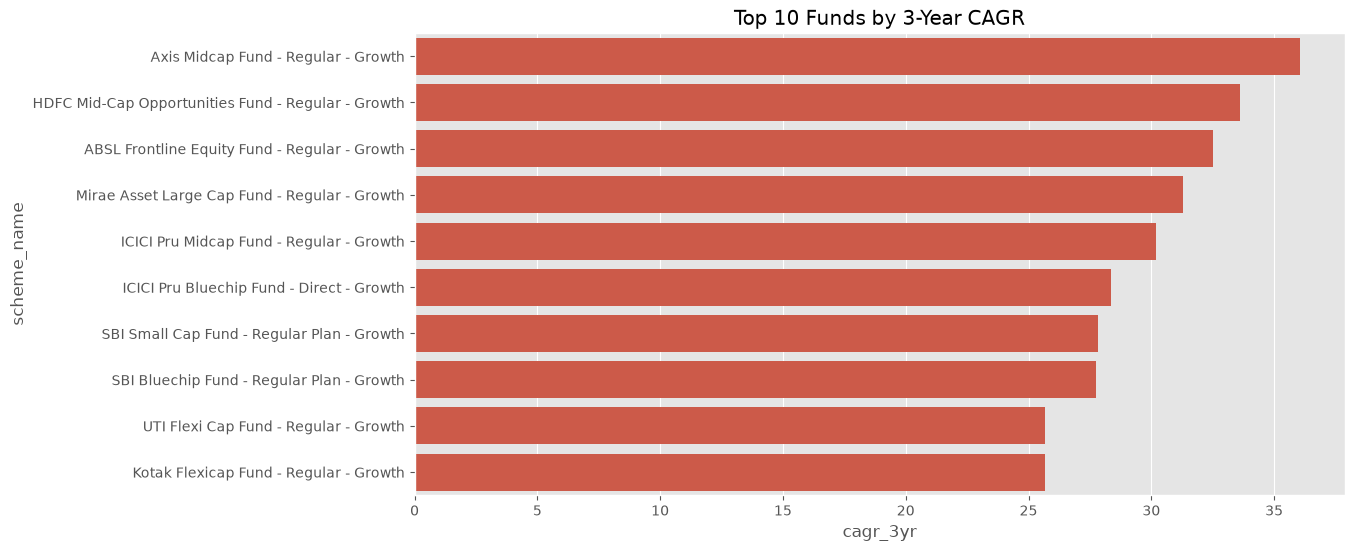

In [15]:
top = cagr_df.sort_values(
    "cagr_3yr",
    ascending=False
).head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top,
    x="cagr_3yr",
    y="scheme_name"
)

plt.title("Top 10 Funds by 3-Year CAGR")

plt.show()

In [16]:
risk_free_rate = 0.065

print("Risk Free Rate:", risk_free_rate)

Risk Free Rate: 0.065


In [17]:
sharpe_list = []

for code in daily_returns["amfi_code"].unique():

    df = daily_returns[daily_returns["amfi_code"] == code]

    mean_return = df["daily_return"].mean() * 252

    std_return = df["daily_return"].std() * np.sqrt(252)

    if std_return != 0:
        sharpe = (mean_return - risk_free_rate) / std_return
    else:
        sharpe = np.nan

    sharpe_list.append([code, sharpe])

sharpe_df = pd.DataFrame(
    sharpe_list,
    columns=["amfi_code", "sharpe_ratio"]
)

sharpe_df.head()

,amfi_code,sharpe_ratio
0,100016,-0.201517
1,100025,-0.567095
2,100033,1.093699
3,101206,1.027213
4,101207,0.162661


In [18]:
sharpe_df.to_csv(
    "../data/processed/sharpe_values.csv",
    index=False
)

print("Sharpe Ratio Saved Successfully ✔")

Sharpe Ratio Saved Successfully ✔


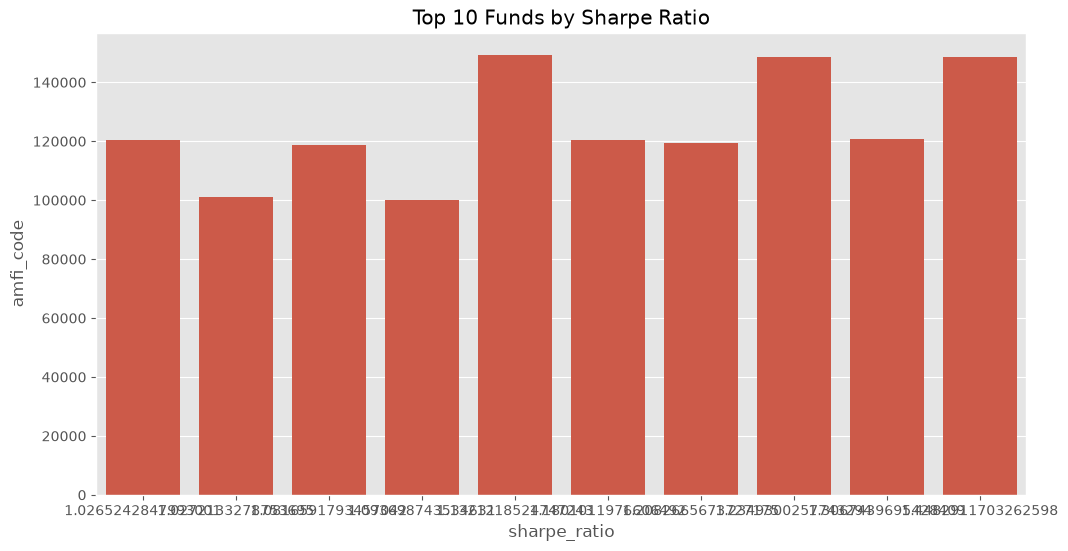

In [19]:
top = sharpe_df.sort_values(
    "sharpe_ratio",
    ascending=False
).head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top,
    x="sharpe_ratio",
    y="amfi_code"
)

plt.title("Top 10 Funds by Sharpe Ratio")

plt.show()

In [20]:
sortino_list = []

for code in daily_returns["amfi_code"].unique():

    df = daily_returns[daily_returns["amfi_code"] == code]

    mean_return = df["daily_return"].mean() * 252

    downside = df[df["daily_return"] < 0]["daily_return"]

    downside_std = downside.std() * np.sqrt(252)

    if downside_std != 0 and not np.isnan(downside_std):
        sortino = (mean_return - risk_free_rate) / downside_std
    else:
        sortino = np.nan

    sortino_list.append([code, sortino])

sortino_df = pd.DataFrame(
    sortino_list,
    columns=["amfi_code", "sortino_ratio"]
)

sortino_df.head()

,amfi_code,sortino_ratio
0,100016,-0.351047
1,100025,-0.941821
2,100033,1.829134
3,101206,1.799563
4,101207,0.276644


In [21]:
sortino_df.to_csv(
    "../data/processed/sortino_values.csv",
    index=False
)

print("Sortino Ratio Saved Successfully ✔")

Sortino Ratio Saved Successfully ✔


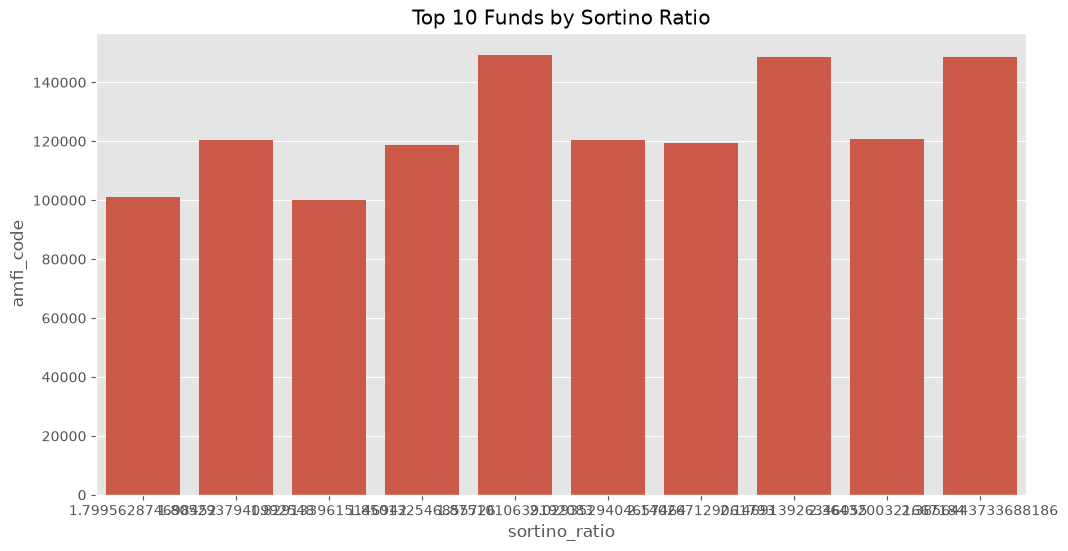

In [22]:
top = sortino_df.sort_values(
    "sortino_ratio",
    ascending=False
).head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top,
    x="sortino_ratio",
    y="amfi_code"
)

plt.title("Top 10 Funds by Sortino Ratio")

plt.show()

In [23]:
benchmark.head()

,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [24]:
benchmark.columns

Index(['date', 'index_name', 'close_value'], dtype='str')

In [25]:
benchmark["date"] = pd.to_datetime(benchmark["date"])

benchmark = benchmark.sort_values(["index_name", "date"])

benchmark["benchmark_return"] = (
    benchmark.groupby("index_name")["close_value"]
    .pct_change()
)

benchmark.head()

,date,index_name,close_value,benchmark_return
3450,2022-01-03,BSE_SMALLCAP,26554.60,NaN
3451,2022-01-04,BSE_SMALLCAP,27079.92,0.019783
3452,2022-01-05,BSE_SMALLCAP,27313.35,0.008620
3453,2022-01-06,BSE_SMALLCAP,27377.05,0.002332
3454,2022-01-07,BSE_SMALLCAP,26316.86,-0.038726


In [26]:
benchmark["index_name"].unique()

<StringArray>
[   'BSE_SMALLCAP',     'CRISIL_GILT',   'CRISIL_LIQUID',        'NIFTY100',
         'NIFTY50',        'NIFTY500', 'NIFTY_MIDCAP150']
Length: 7, dtype: str

In [32]:
nifty100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

nifty100.head()

,date,index_name,close_value,benchmark_return
1150,2022-01-03,NIFTY100,17778.24,NaN
1151,2022-01-04,NIFTY100,17537.52,-0.013540
1152,2022-01-05,NIFTY100,17607.73,0.004003
1153,2022-01-06,NIFTY100,17556.05,-0.002935
1154,2022-01-07,NIFTY100,17664.02,0.006150


In [33]:
merged = pd.merge(
    daily_returns,
    nifty100[["date", "benchmark_return"]],
    on="date",
    how="inner"
)

merged.head()

,amfi_code,date,nav,daily_return,benchmark_return
0,100016,2022-01-04,515.0971,-0.010306,-0.013540
1,100016,2022-01-05,521.7239,0.012865,0.004003
2,100016,2022-01-06,515.7880,-0.011377,-0.002935
3,100016,2022-01-07,515.1639,-0.001210,0.006150
4,100016,2022-01-10,510.7136,-0.008639,-0.008351


In [34]:
alpha_beta = []

for code in merged["amfi_code"].unique():

    df = merged[merged["amfi_code"] == code]

    if len(df) > 30:

        slope, intercept, r, p, std = linregress(
            df["benchmark_return"],
            df["daily_return"]
        )

        alpha = intercept * 252
        beta = slope

        alpha_beta.append([
            code,
            alpha,
            beta
        ])

alpha_beta_df = pd.DataFrame(
    alpha_beta,
    columns=[
        "amfi_code",
        "alpha",
        "beta"
    ]
)

alpha_beta_df.head()

,amfi_code,alpha,beta
0,100016,0.037476,-0.058268
1,100025,0.042818,0.001158
2,100033,0.271954,0.005104
3,101206,0.213998,0.021086
4,101207,0.108971,-0.065289


In [35]:
alpha_beta_df.to_csv(
    "../data/processed/alpha_beta.csv",
    index=False
)
alpha_beta_df.to_csv(
    "../data/processed/alpha_beta.csv",
    index=False
)

print("Alpha Beta Report Saved Successfully ✔")
print("Alpha Beta Report Saved ✔")

Alpha Beta Report Saved Successfully ✔
Alpha Beta Report Saved ✔


In [31]:
benchmark["index_name"].unique()

<StringArray>
[   'BSE_SMALLCAP',     'CRISIL_GILT',   'CRISIL_LIQUID',        'NIFTY100',
         'NIFTY50',        'NIFTY500', 'NIFTY_MIDCAP150']
Length: 7, dtype: str

In [37]:
drawdown_list = []

for code in nav["amfi_code"].unique():

    df = nav[nav["amfi_code"] == code].copy()

    df = df.sort_values("date")

    df["running_max"] = df["nav"].cummax()

    df["drawdown"] = (df["nav"] - df["running_max"]) / df["running_max"]

    max_dd = df["drawdown"].min()

    drawdown_list.append([code, max_dd])

drawdown_df = pd.DataFrame(
    drawdown_list,
    columns=["amfi_code", "max_drawdown"]
)

drawdown_df.head()

,amfi_code,max_drawdown
0,100016,-0.247344
1,100025,-0.043083
2,100033,-0.162172
3,101206,-0.112916
4,101207,-0.354469


In [38]:
drawdown_df.to_csv(
    "../data/processed/max_drawdown.csv",
    index=False
)

print("Maximum Drawdown Report Saved ✔")

Maximum Drawdown Report Saved ✔


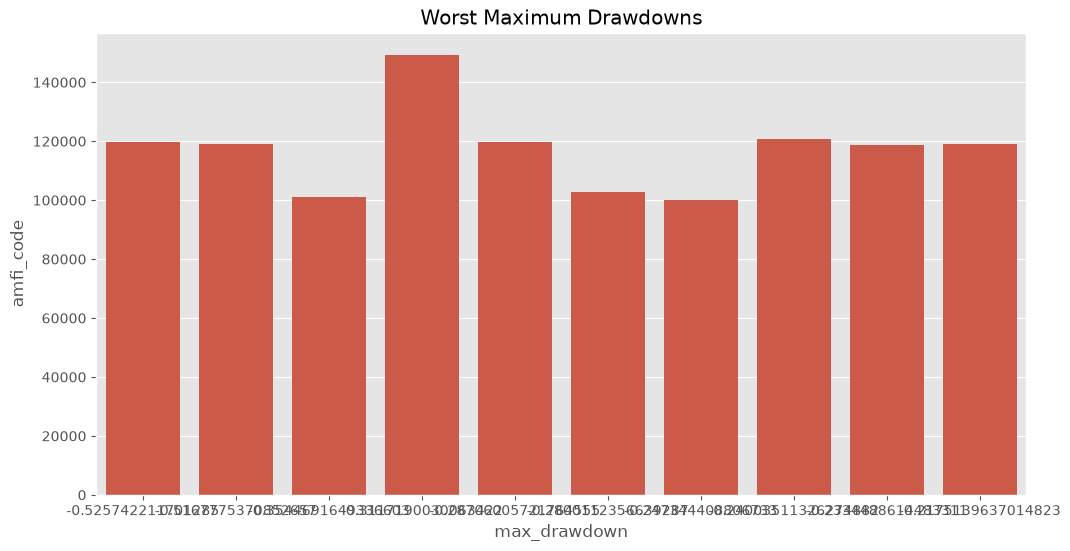

In [39]:
top = drawdown_df.sort_values(
    "max_drawdown"
).head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top,
    x="max_drawdown",
    y="amfi_code"
)

plt.title("Worst Maximum Drawdowns")

plt.show()

In [40]:
scorecard = performance[["amfi_code", "scheme_name"]].copy()

scorecard = scorecard.merge(
    cagr_df[["amfi_code", "cagr_3yr"]],
    on="amfi_code",
    how="left"
)

scorecard = scorecard.merge(
    sharpe_df,
    on="amfi_code",
    how="left"
)

scorecard = scorecard.merge(
    alpha_beta_df,
    on="amfi_code",
    how="left"
)

scorecard = scorecard.merge(
    drawdown_df,
    on="amfi_code",
    how="left"
)

scorecard.head()

,amfi_code,scheme_name,cagr_3yr,sharpe_ratio,alpha,beta,max_drawdown
0,119551,SBI Bluechip Fund - Regular Plan - Growth,27.727428,1.208267,0.232010,-0.031751,-0.150124
1,119552,SBI Bluechip Fund - Direct Plan - Growth,15.383383,0.953279,0.198686,-0.026159,-0.118035
2,119598,SBI Small Cap Fund - Regular Plan - Growth,27.814418,0.945308,0.303370,-0.023196,-0.287060
3,119599,SBI Small Cap Fund - Direct Plan - Growth,-0.686612,-0.057187,0.048824,0.062002,-0.525742
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,5.606029,-0.226575,0.056209,-0.006414,-0.043287


In [42]:
scorecard["return_rank"] = scorecard["cagr_3yr"].rank(ascending=False)

scorecard["sharpe_rank"] = scorecard["sharpe_ratio"].rank(ascending=False)

scorecard["alpha_rank"] = scorecard["alpha"].rank(ascending=False)

scorecard["drawdown_rank"] = scorecard["max_drawdown"].rank(ascending=True)

In [43]:
scorecard["fund_score"] = (

0.30 * scorecard["return_rank"]

+

0.25 * scorecard["sharpe_rank"]

+

0.20 * scorecard["alpha_rank"]

+

0.25 * scorecard["drawdown_rank"]

)

scorecard = scorecard.sort_values(
    "fund_score"
)

scorecard.head(10)

,amfi_code,scheme_name,cagr_3yr,sharpe_ratio,alpha,beta,max_drawdown,return_rank,sharpe_rank,alpha_rank,drawdown_rank,fund_score
2,119598,SBI Small Cap Fund - Regular Plan - Growth,27.814418,0.945308,0.303370,-0.023196,-0.287060,7.0,14.0,1.0,5.0,7.05
12,120505,ICICI Pru Midcap Fund - Regular - Growth,30.206535,1.180101,0.292636,0.000549,-0.181885,5.0,5.0,3.0,16.0,7.35
39,149324,DSP Small Cap Fund - Regular - Growth,25.029675,0.949796,0.300579,0.011455,-0.311719,11.0,13.0,2.0,4.0,7.95
26,119094,Axis Midcap Fund - Regular - Growth,36.066017,0.998231,0.260767,-0.066265,-0.209609,1.0,11.0,9.0,13.0,8.10
7,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,33.629211,1.093699,0.271954,0.005104,-0.162172,2.0,7.0,6.0,21.0,8.80
36,148569,Mirae Asset Tax Saver Fund - Regular - Growth,23.317123,1.234930,0.282704,0.018134,-0.163967,13.0,3.0,4.0,20.0,10.45
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,31.278573,1.448291,0.269838,0.023684,-0.112657,4.0,1.0,7.0,33.0,11.10
0,119551,SBI Bluechip Fund - Regular Plan - Growth,27.727428,1.208267,0.232010,-0.031751,-0.150124,8.0,4.0,10.0,24.0,11.40
38,149323,DSP Midcap Fund - Regular - Growth,24.242465,1.132122,0.265986,-0.002523,-0.172481,12.0,6.0,8.0,19.0,11.45
22,120843,Kotak Flexicap Fund - Regular - Growth,25.661883,1.306744,0.273305,-0.022830,-0.129740,10.0,2.0,5.0,28.0,11.50


In [44]:
scorecard.to_csv(
    "../data/processed/fund_scorecard.csv",
    index=False
)

print("Fund Scorecard Saved ✔")

Fund Scorecard Saved ✔


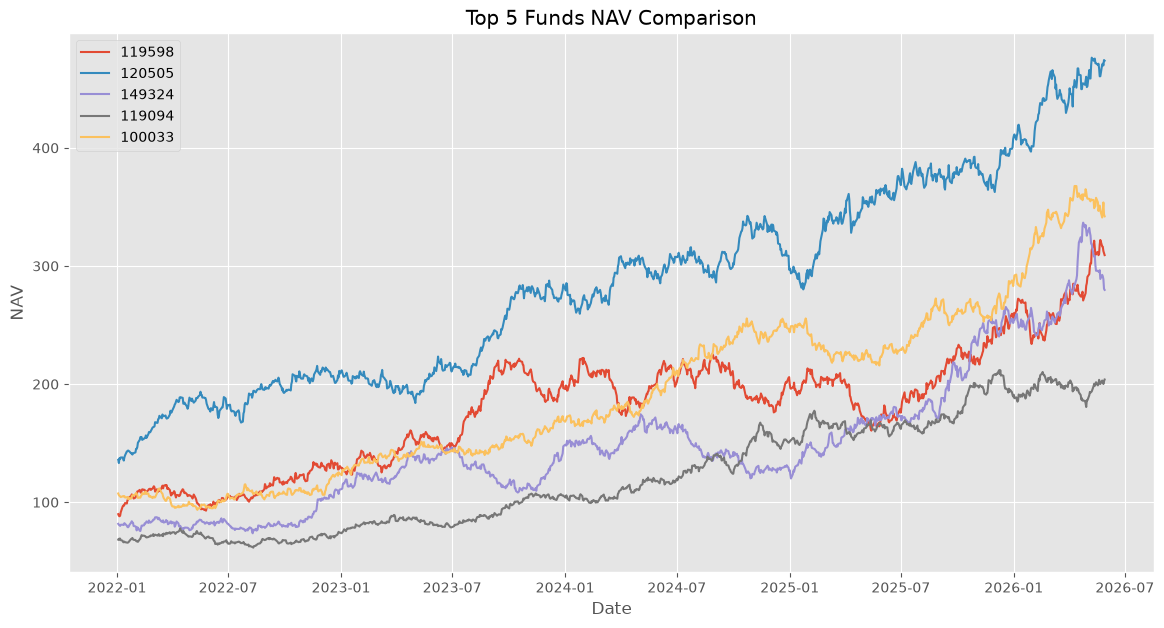

In [45]:
top5 = scorecard.head(5)["amfi_code"]

plt.figure(figsize=(14,7))

for code in top5:

    df = nav[nav["amfi_code"] == code]

    plt.plot(
        df["date"],
        df["nav"],
        label=str(code)
    )

plt.legend()

plt.title("Top 5 Funds NAV Comparison")

plt.xlabel("Date")

plt.ylabel("NAV")

plt.show()

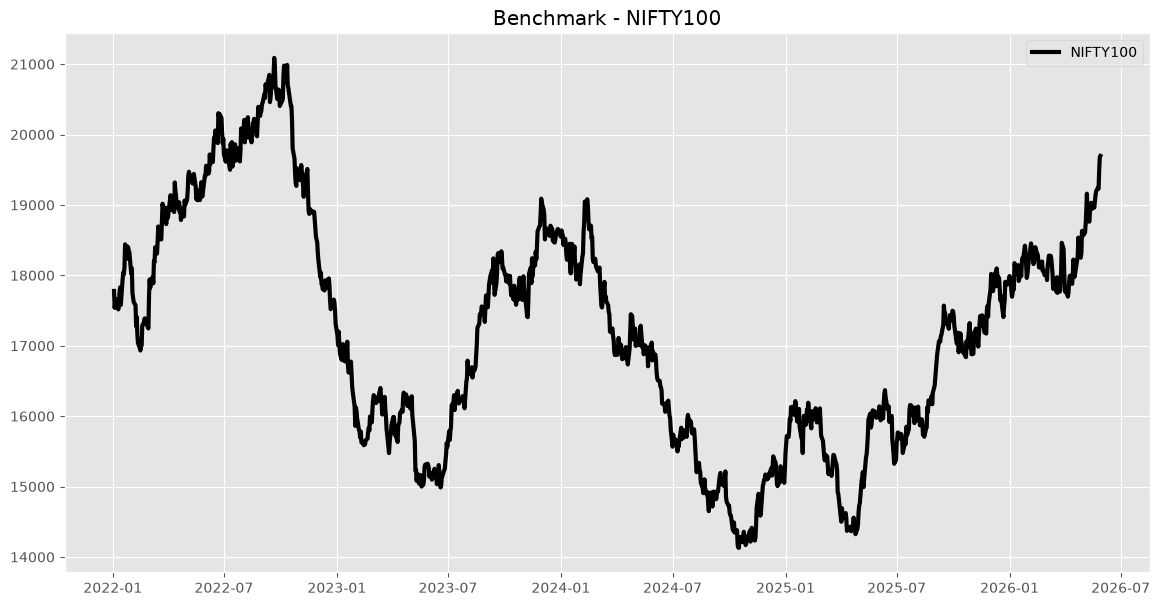

In [46]:
benchmark_plot = benchmark[
    benchmark["index_name"] == "NIFTY100"
]

plt.figure(figsize=(14,7))

plt.plot(
    benchmark_plot["date"],
    benchmark_plot["close_value"],
    color="black",
    linewidth=3,
    label="NIFTY100"
)

plt.legend()

plt.title("Benchmark - NIFTY100")

plt.show()

In [47]:
print("DAY 4 COMPLETED SUCCESSFULLY ✔")

DAY 4 COMPLETED SUCCESSFULLY ✔
